<a href="https://colab.research.google.com/github/Sneha-1503/DataAnalyisis_Task2/blob/main/Task2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [6]:
from google.colab import files
uploaded = files.upload()

Saving products-100.csv to products-100.csv


In [8]:
df = pd.read_csv("products-100.csv")
df.head()

,Index,Name,Description,Brand,Category,Price,Currency,Stock,EAN,Color,Size,Availability,Internal ID
0,1,Compact Printer Air Advanced Digital,Situation organization these memory much off.,"Garner, Boyle and Flynn",Books & Stationery,265,USD,774,2.091470e+12,ForestGreen,Large,pre_order,56
1,2,Tablet,Discussion loss politics free one thousand.,Mueller Inc,Shoes & Footwear,502,USD,81,5.286200e+12,Black,8x10 in,in_stock,29
2,3,Smart Blender Cooker,No situation per.,"Lawson, Keller and Winters",Kitchen Appliances,227,USD,726,1.282900e+12,SlateGray,XS,in_stock,70
3,4,Advanced Router Rechargeable,For force gas energy six laugh.,Gallagher and Sons,Kitchen Appliances,121,USD,896,3.879180e+12,PaleGreen,L,discontinued,31
4,5,Portable Mouse Monitor Phone,Feeling back religious however author room sci...,Irwin LLC,Kids' Clothing,1,USD,925,9.055770e+12,SeaShell,100x200 mm,discontinued,10


In [9]:
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Index         100 non-null    int64  
 1   Name          100 non-null    object 
 2   Description   100 non-null    object 
 3   Brand         100 non-null    object 
 4   Category      100 non-null    object 
 5   Price         100 non-null    int64  
 6   Currency      100 non-null    object 
 7   Stock         100 non-null    int64  
 8   EAN           100 non-null    float64
 9   Color         100 non-null    object 
 10  Size          100 non-null    object 
 11  Availability  100 non-null    object 
 12  Internal ID   100 non-null    int64  
dtypes: float64(1), int64(4), object(8)
memory usage: 10.3+ KB

Missing Values:
Index           0
Name            0
Description     0
Brand           0
Category        0
Price           0
Currency        0
Stock           0
EAN             0
Color    

In [10]:
df.dropna(inplace=True)

le = LabelEncoder()

for col in ['Brand', 'Category', 'Color', 'Size', 'Availability']:
    df[col] = le.fit_transform(df[col])

df.head()

,Index,Name,Description,Brand,Category,Price,Currency,Stock,EAN,Color,Size,Availability,Internal ID
0,1,Compact Printer Air Advanced Digital,Situation organization these memory much off.,35,4,265,USD,774,2.091470e+12,21,9,5,56
1,2,Tablet,Discussion loss politics free one thousand.,70,25,502,USD,81,5.286200e+12,5,6,2,29
2,3,Smart Blender Cooker,No situation per.,54,20,227,USD,726,1.282900e+12,64,15,2,70
3,4,Advanced Router Rechargeable,For force gas energy six laugh.,32,20,121,USD,896,3.879180e+12,51,8,1,31
4,5,Portable Mouse Monitor Phone,Feeling back religious however author room sci...,47,19,1,USD,925,9.055770e+12,60,0,1,10


In [11]:
X = df[['Brand', 'Category', 'Price', 'Stock', 'Color', 'Size']]
y = df['Availability']

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (100, 6)
Target Shape: (100,)


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 80
Testing Samples: 20


In [13]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model Training Completed!")

Model Training Completed!


In [14]:
y_pred = model.predict(X_test)

print("Predictions Generated!")

Predictions Generated!


In [15]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy * 100, 2), "%")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 30.0 %

Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       0.50      0.50      0.50         2
           2       0.25      0.20      0.22         5
           3       0.00      0.00      0.00         3
           4       0.00      0.00      0.00         3
           5       0.44      0.57      0.50         7

    accuracy                           0.30        20
   macro avg       0.20      0.21      0.20        20
weighted avg       0.27      0.30      0.28        20



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

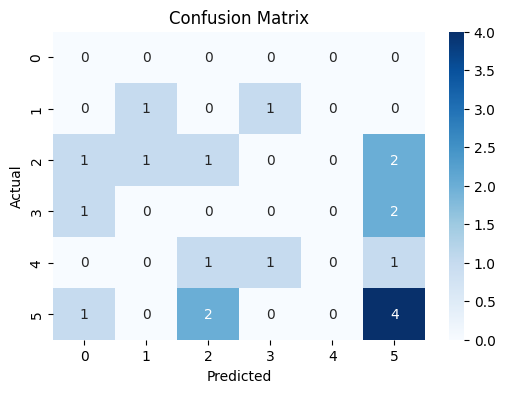

In [16]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [17]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

    Feature  Importance
2     Price    0.199820
4     Color    0.175470
1  Category    0.172076
0     Brand    0.170477
3     Stock    0.156204
5      Size    0.125954


In [18]:
print("""
Project: Predicting Product Availability Using Machine Learning

Algorithm Used: Random Forest Classifier

Evaluation Metrics:
- Accuracy Score
- Classification Report
- Confusion Matrix

Outcome:
The model predicts product availability based on product attributes
such as brand, category, stock quantity, price, color, and size.
""")


Project: Predicting Product Availability Using Machine Learning

Algorithm Used: Random Forest Classifier

Evaluation Metrics:
- Accuracy Score
- Classification Report
- Confusion Matrix

Outcome:
The model predicts product availability based on product attributes
such as brand, category, stock quantity, price, color, and size.

